# Sensitivity Analysis and Fisher Information for a Diffractive Lens

Notebook version of `examples/scripts/sensitivity_analysis.py`. This example analyzes a nominal diffractive phase mask over the **full square grid** (no aperture stop) from two complementary viewpoints:

- **Measurement informativeness**: how well the focal-plane intensity can estimate the incident angle via a Fisher Information Matrix (FIM).
- **Design robustness**: which phase pixels are most sensitive and what fabrication perturbation they can tolerate.

> **Introduction (what this notebook does)**  
> We build a stretched hyperbolic phase mask, illuminate it with a coherent plane wave whose intensity is set by `INPUT_COUNT_SCALE`, and propagate to a sensor plane. We then compute (1) the angle-of-incidence FIM and Cram\'er-Rao bounds under a Poisson noise model, and (2) per-pixel phase sensitivity and tolerance maps for the same optical design.

### Outline

0. **Imports** for optics simulation and analysis utilities.
1. **Paths and Parameters** defining the grid, wavelength, propagation distance, nominal tilt, and photon-count scale.
2. **Helper Functions** for the stretched hyperbolic phase profile.
3. **Setup** of the optical module and differentiable forward models.
4. **Observation Fisher Information** for angle-of-incidence estimation.
5. **Design Sensitivity Analysis** for phase robustness and tolerance.
6. **Plot Results** with phase, focal spot + FIM summary, and design maps.


## 0  Imports

We use `fouriax.optics` to build the coherent propagation model and `fouriax.analysis` for local sensitivity and estimation-theory metrics.

`jax.numpy` keeps the forward model differentiable, while NumPy/Matplotlib are used for array conversion and visualization.


In [1]:
from __future__ import annotations

# NOTEBOOK_REPO_ROOT_SETUP
import os
from pathlib import Path as _Path
%matplotlib inline

def _find_repo_root(start: _Path) -> _Path:
    for candidate in (start, *start.parents):
        if (
            (candidate / "src" / "fouriax").exists()
            and (candidate / "README.md").exists()
        ):
            return candidate
    raise FileNotFoundError(
        "Could not locate repository root from current working directory. "
        "Expected to find src/fouriax and README.md in an ancestor."
    )

REPO_ROOT = _find_repo_root(_Path.cwd())
if _Path.cwd() != REPO_ROOT:
    os.chdir(REPO_ROOT)


## 1  Paths and Parameters

This section defines the simulation size, wavelength, propagation distance, the nominal incident tilt used for the FIM calculation, and `INPUT_COUNT_SCALE`.

`INPUT_COUNT_SCALE` controls the input plane-wave intensity (via field amplitude $\propto \sqrt{\text{scale}}$). Under the Poisson model used later, the predicted focal-plane intensity also sets the noise variance:

$$
\mathrm{Var}[Y_i] = \mu_i,
$$

so increasing `INPUT_COUNT_SCALE` increases both the expected counts and the information available for angle estimation.

A few other parameters are especially important:

- `STRETCH_FACTOR` introduces anisotropy in the phase profile so the lens response is directionally different.
- `NOMINAL_ANGLE_RAD` and `NOMINAL_DIRECTION_DEG` set the operating point $\boldsymbol{\theta}_0$ around which the local FIM is computed.
- `PLOT_PATH` stores a single summary figure containing both measurement and design analyses.


In [2]:
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from fouriax.analysis import (
    cramer_rao_bound,
    d_optimality,
    fisher_information,
    sensitivity_map,
)
from fouriax.optics import (
    Field,
    Grid,
    OpticalModule,
    PhaseMask,
    PoissonNoise,
    Spectrum,
    plan_propagation,
)

ARTIFACTS_DIR = Path('artifacts')
PLOT_PATH = ARTIFACTS_DIR / "sensitivity_analysis_overview.png"

SEED = 0
GRID_N = 32
GRID_DX_UM = 1.0
WAVELENGTH_UM = 0.532
DISTANCE_UM = 150.0
NOMINAL_ANGLE_RAD = 0.005
NOMINAL_DIRECTION_DEG = 0.0
STRETCH_FACTOR = 1.5
INPUT_COUNT_SCALE = 1000.0
SENSITIVITY_POOL = 4
PLOT = True


## 2  Helper Functions

The helper function defines a stretched hyperbolic phase profile, which acts like an anisotropic focusing element:

$$
\phi(x,y) = -k\Bigl(\sqrt{s x^2 + y^2 + z^2} - z\Bigr),
\qquad k = \frac{2\pi}{\lambda}.
$$

Here $s=\texttt{stretch\_factor}$. When $s \ne 1$, the phase curvature differs along $x$ and $y$, so the response to incident angle becomes direction-dependent. That anisotropy makes both the FIM and design sensitivity maps more informative than in the perfectly symmetric case.


In [3]:
def stretched_hyperbolic_phase(
    grid: Grid,
    distance_um: float,
    wavelength_um: float,
    stretch_factor: float = 2.0,
) -> jnp.ndarray:
    x, y = grid.spatial_grid()
    k = 2.0 * jnp.pi / wavelength_um
    return -k * (jnp.sqrt(stretch_factor * x * x + y * y + distance_um**2) - distance_um)


def pooled_metric(image: jnp.ndarray, pool: int) -> jnp.ndarray:
    if pool <= 1:
        return image.ravel()
    if image.shape[0] % pool != 0 or image.shape[1] % pool != 0:
        raise ValueError(
            "sensitivity_pool must divide both image dimensions; "
            f"got pool={pool} for shape={image.shape}"
        )
    pooled = image.reshape(
        image.shape[0] // pool,
        pool,
        image.shape[1] // pool,
        pool,
    ).mean(axis=(1, 3))
    return pooled.ravel()


## 3  Setup

We instantiate the grid, spectrum, and a propagation layer, then define a compact optical pipeline consisting of a phase mask followed by free-space propagation:

$$
E_{\mathrm{out}} = \mathcal{P}_z\!\left\{e^{i\phi(x,y)} E_{\mathrm{in}}(x,y)\right\}.
$$

There is no aperture mask in this version, so the **entire square simulation grid** is the design region for the phase.

Two closures are defined:

- `forward_intensity(phase_map)` returns the focal-plane intensity image used by the design-sensitivity routines.
- `forward_angle(angles)` returns the flattened focal-plane intensity used by the Fisher-information calculation.

Both are written as pure functions so JAX can differentiate them directly.


In [4]:
if SENSITIVITY_POOL <= 0:
    raise ValueError("sensitivity_pool must be strictly positive")
grid = Grid.from_extent(nx=GRID_N, ny=GRID_N, dx_um=GRID_DX_UM, dy_um=GRID_DX_UM)
spectrum = Spectrum.from_scalar(WAVELENGTH_UM)
propagator = plan_propagation(
    mode="auto",
    grid=grid,
    spectrum=spectrum,
    distance_um=DISTANCE_UM,
)

# Use a hyperbolic lens phase as the "optimized" design
phase = stretched_hyperbolic_phase(grid, DISTANCE_UM, WAVELENGTH_UM, STRETCH_FACTOR)

def make_module(phase_map: jnp.ndarray) -> OpticalModule:
    return OpticalModule(
        layers=(
            PhaseMask(phase_map_rad=phase_map[None, :, :]),
            propagator,
        )
    )

input_amp = jnp.sqrt(jnp.asarray(INPUT_COUNT_SCALE, dtype=jnp.float32))
field_in = Field.plane_wave(grid=grid, spectrum=spectrum, amplitude=input_amp)

def forward_intensity(phase_map: jnp.ndarray) -> jnp.ndarray:
    return make_module(phase_map).forward(field_in).intensity()[0]


## 4  Observation Fisher Information (angle of incidence)

This section computes the local information available for estimating the incident tilt vector

$$
\boldsymbol{\theta} = (\theta_x, \theta_y),
$$

implemented as a small-angle phase ramp

$$
E_{\mathrm{in}}(x,y;\boldsymbol{\theta}) = \sqrt{I_0}\,\exp\!\bigl(i k (\theta_x x + \theta_y y)\bigr),
$$

where $I_0 = \texttt{INPUT\_COUNT\_SCALE}$ is the input intensity/count scale.

The forward model returns the flattened focal-plane intensity $\mu(\boldsymbol{\theta})$. Under a Poisson noise model, the Fisher Information Matrix is

$$
\mathbf{F}(\boldsymbol{\theta}) = \mathbf{J}^\top \operatorname{diag}\!\left(\frac{1}{\mu}\right) \mathbf{J},
\qquad
\mathbf{J} = \frac{\partial \mu}{\partial \boldsymbol{\theta}}.
$$

From this we compute the Cramer-Rao bound (CRB) and D-optimality before moving on to phase-design robustness.


In [5]:
k = 2.0 * jnp.pi / WAVELENGTH_UM
x_grid, y_grid = grid.spatial_grid()

def forward_angle(angles: jnp.ndarray) -> jnp.ndarray:
    """Map (θ_x, θ_y) → focal-plane intensity."""
    theta_x, theta_y = angles[0], angles[1]
    tilt_phase = k * (theta_x * x_grid + theta_y * y_grid)
    field_data = (input_amp * jnp.exp(1j * tilt_phase)).astype(jnp.complex64)
    field_tilted = Field(
        data=field_data[None, :, :],
        grid=grid,
        spectrum=spectrum,
        domain="spatial",
    )
    return make_module(phase).forward(field_tilted).intensity()[0].ravel()

# Off-axis nominal angle at the configured direction
angle_dir = jnp.deg2rad(NOMINAL_DIRECTION_DEG)
angles_nominal = NOMINAL_ANGLE_RAD * jnp.array(
    [jnp.cos(angle_dir), jnp.sin(angle_dir)],
)
print("Computing observation FIM (angle of incidence)...")
fim_angle = fisher_information(
    forward_angle,
    angles_nominal,
    noise_model=PoissonNoise(count_scale=1.0),
)
crb_angle = cramer_rao_bound(fim_angle, regularize=1e-15)
d_opt = d_optimality(fim_angle)

fim_np = np.asarray(fim_angle)
crb_np = np.asarray(crb_angle)
print(f"FIM (2×2):\n{fim_np}")
print(f"CRB (θ_x, θ_y): ({crb_np[0]:.3e}, {crb_np[1]:.3e}) rad²")
print(
    f"Angular precision: σ_θx={np.sqrt(max(crb_np[0], 0)):.3e}, "
    f"σ_θy={np.sqrt(max(crb_np[1], 0)):.3e} rad"
)
print(f"D-optimality: {float(d_opt):.2f}")


Computing observation FIM (angle of incidence)...


FIM (2×2):
[[ 3.3679967e+09 -4.8084431e+05]
 [-4.8080309e+05  2.8830224e+10]]
CRB (θ_x, θ_y): (2.969e-10, 3.469e-11) rad²
Angular precision: σ_θx=1.723e-05, σ_θy=5.889e-06 rad
D-optimality: 46.02


## 5  Design Sensitivity Analysis

After characterizing measurement informativeness, we analyze how the output intensity image changes when each phase pixel is perturbed.

If $I(\phi)$ denotes the flattened output intensity and $\phi_i$ is one phase parameter, the sensitivity map reports the Jacobian column norm

$$
s_i = \left\|\frac{\partial I}{\partial \phi_i}\right\|_2.
$$

Large $s_i$ means that small fabrication error at pixel $i$ produces a large change in the measured intensity.

The tolerance map uses a first-order estimate for an allowed output change $\Delta I_{\text{target}}$ (here `0.01`):

$$
\Delta \phi_i \approx \frac{\Delta I_{\text{target}}}{s_i}.
$$

Because there is no aperture, these maps are defined over the full square phase-design region.


In [6]:
print("Computing design sensitivity (per-pixel phase sensitivity)...")
def metric_fn(output: jnp.ndarray) -> jnp.ndarray:
    return pooled_metric(output, SENSITIVITY_POOL)

sens = sensitivity_map(forward_intensity, phase, metric_fn=metric_fn)
sens_np = np.asarray(sens)

print("Computing fabrication tolerance map...")
tol = 0.01 / jnp.maximum(sens, 1e-12)
tol_np = np.asarray(tol)


Computing design sensitivity (per-pixel phase sensitivity)...


Computing fabrication tolerance map...


## 6  Plot Results

The final figure is a 2×2 summary with the **measurement-oriented views first**:

- **Top-left:** wrapped phase mask (the full square design region)
- **Top-right:** focal spot at the nominal angle with an overlaid FIM/CRB/D-optimality summary box
- **Bottom-left:** phase sensitivity map (higher means more fragile parameters)
- **Bottom-right:** fabrication tolerance map (larger allowable phase error is better)

This layout makes it easier to connect the measurement behavior (focal spot + FIM) to the underlying phase design and its robustness.


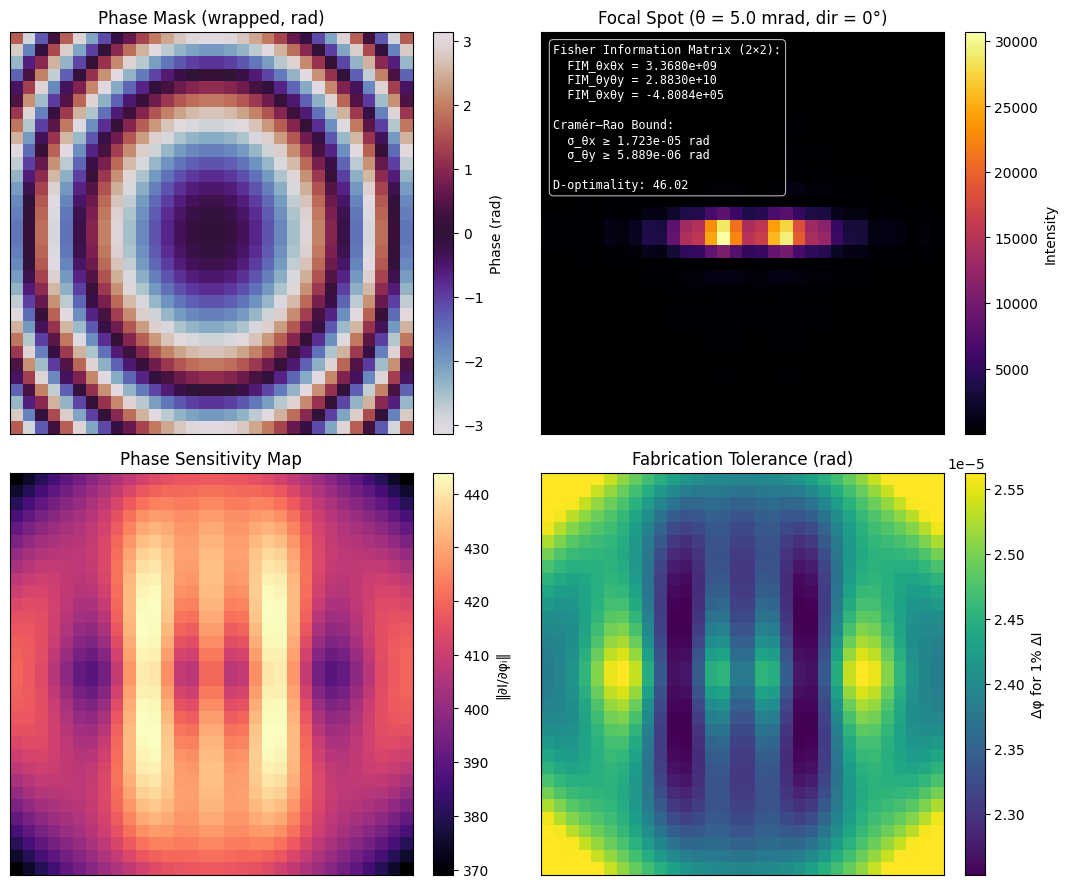

saved: artifacts/sensitivity_analysis_overview.png


In [7]:
if PLOT:
    ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

    fig, axes = plt.subplots(2, 2, figsize=(11.5, 9.0))

    phase_wrapped = np.angle(np.exp(1j * np.asarray(phase)))
    im0 = axes[0, 0].imshow(phase_wrapped, cmap="twilight", vmin=-np.pi, vmax=np.pi)
    axes[0, 0].set_title("Phase Mask (wrapped, rad)")
    axes[0, 0].set_xticks([])
    axes[0, 0].set_yticks([])
    plt.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04, label="Phase (rad)")

    intensity = np.asarray(
        forward_angle(angles_nominal).reshape(GRID_N, GRID_N),
    )
    im1 = axes[0, 1].imshow(intensity, cmap="inferno")
    theta_mrad = float(NOMINAL_ANGLE_RAD * 1e3)
    axes[0, 1].set_title(
        f"Focal Spot (θ = {theta_mrad:.1f} mrad, dir = {NOMINAL_DIRECTION_DEG:.0f}°)",
    )
    axes[0, 1].set_xticks([])
    axes[0, 1].set_yticks([])
    plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04, label="Intensity")
    axes[0, 1].text(
        0.03,
        0.97,
        (
            f"Fisher Information Matrix (2×2):\n"
            f"  FIM_θxθx = {fim_np[0, 0]:.4e}\n"
            f"  FIM_θyθy = {fim_np[1, 1]:.4e}\n"
            f"  FIM_θxθy = {fim_np[0, 1]:.4e}\n\n"
            f"Cramér–Rao Bound:\n"
            f"  σ_θx ≥ {np.sqrt(max(crb_np[0], 0)):.3e} rad\n"
            f"  σ_θy ≥ {np.sqrt(max(crb_np[1], 0)):.3e} rad\n\n"
            f"D-optimality: {float(d_opt):.2f}"
        ),
        transform=axes[0, 1].transAxes,
        va="top",
        ha="left",
        fontsize=8.5,
        family="monospace",
        color="white",
        bbox={
            "boxstyle": "round,pad=0.35",
            "facecolor": "black",
            "alpha": 0.70,
            "edgecolor": "white",
            "linewidth": 0.8,
        },
    )

    im2 = axes[1, 0].imshow(sens_np, cmap="magma")
    axes[1, 0].set_title("Phase Sensitivity Map")
    axes[1, 0].set_xticks([])
    axes[1, 0].set_yticks([])
    plt.colorbar(im2, ax=axes[1, 0], fraction=0.046, pad=0.04, label="‖∂I/∂φᵢ‖")

    tol_clipped = np.clip(tol_np, 0, np.nanpercentile(tol_np, 95))
    im3 = axes[1, 1].imshow(tol_clipped, cmap="viridis")
    axes[1, 1].set_title("Fabrication Tolerance (rad)")
    axes[1, 1].set_xticks([])
    axes[1, 1].set_yticks([])
    plt.colorbar(im3, ax=axes[1, 1], fraction=0.046, pad=0.04, label="Δφ for 1% ΔI")

    fig.tight_layout()
    fig.savefig(PLOT_PATH, dpi=150)
    plt.show()
    print(f"saved: {PLOT_PATH}")
